# Seq2seq 한국어-영어 번역기 만들기 Quest      (by 김민수)

- 4/30: 노드1 일부 진행하다가 종료
- 5/6: 오전에 노드 접속되어 노드1 완료, 단 노드2는 하루 종일 접속 실패
- 5/7: 역시 하루 종일 노드 접속 실패 (노드 내용을 볼수 없으니, 내용 파악이 전혀 안되어 CoLab으로도 작업 불가)
- 5/8: 신규 모듈 시작 및 교재 학습으로 인해 작업 불가 (노드 접속은 여전히 불안정)
- 5/11: 노드 접속 및 학습 진행 (여전히 노드 접속은 중간중간 다운됨)

< Review >
    
    - 전체 작업시간의 20% 정도를 MeCab 사전 설치 문제에 소비했다. 
    - 이로 인해 문장 전처리나 하이퍼 파라미터 최적화에 많은 시간을 들이지 못했다. 
    - Epoch 20회를 돌리면서 Loss가 5.29 -> 3.11 로 줄어들었으나 여전히 다소 높은 수준이며,
    - 번역 결과 역시 대부분 정상 수준에 미치지 못했다. 
    - Attention Heat map에서도 정확한 단어에 Attention을 주지 못하였다.
    

In [86]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


In [38]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)
print(pd.__version__)

2.7.1+cu118
2.3.0


1. 데이터 다운로드

In [7]:
import tarfile
    
# 다운로드 경로 및 파일명 설정
url = "https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz"
file_name = "korean-english-park.train.tar.gz"

print("다운로드 중...")
urllib.request.urlretrieve(url, file_name)

print("압축 해제 중...")
with tarfile.open(file_name, "r:gz") as tar:
    tar.extractall()

print("완료! 현재 디렉토리에 파일이 생성되었습니다.")

# 파일 목록 확인
os.listdir()

다운로드 중...
압축 해제 중...


/tmp/ipykernel_501/2809363846.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


완료! 현재 디렉토리에 파일이 생성되었습니다.


['seq2seq_Quest_260508_v1.ipynb',
 '.ipynb_checkpoints',
 'LSTM_260506.ipynb',
 'korean-english-park.train.ko',
 'datasets',
 'korean-english-park.train.en',
 'korean-english-park.train.tar.gz']

2. 데이터 전처리: 정규식 확징 + 정제

In [39]:
# 한글 전용 전처리 작업

def preprocess_sentence(sentence, s_token=False, e_token=False):
    sentence = sentence.lower().strip()

    # 1. 문장 부호 양옆에 공백 추가
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)

    # 2. 한글, 영문, 숫자, 문장 부호 제외하고 모두 제거
    # [^가-힣ㄱ-ㅎㅏ-ㅣa-zA-Z0-9?.!,]
    sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣa-zA-Z0-9?.!,]+", " ", sentence)

    sentence = sentence.strip()

    # 3. 영문(타겟)일 경우 토큰 추가
    if s_token:
        sentence = '<start> ' + sentence
    if e_token:
        sentence = sentence + ' <end>'

    return sentence

In [47]:
!pip install python-mecab-ko

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 579.6/579.6 kB 5.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 52.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [python-mecab-ko]dic]


In [51]:
# MeCab 설치
from mecab import MeCab
mecab = MeCab()
print(mecab.morphs("안녕하세요"))

['안녕', '하', '세요']


In [50]:
# 중복 제거 및 정제

from mecab import MeCab          # 설치 오류가 반복되어 konlpy Mecab 대신 python-mecab-ko로 변경
mecab = MeCab()

def load_and_clean_data(kor_path, eng_path):
    with open(kor_path, "r", encoding="utf-8") as f: kor_raw = f.read().splitlines()
    with open(eng_path, "r", encoding="utf-8") as f: eng_raw = f.read().splitlines()

    raw_corpus = set(zip(kor_raw, eng_raw))
    cleaned_corpus = []
    kor_corpus = []
    eng_corpus = []

    for kor, eng in tqdm(raw_corpus):
        kor_pre = preprocess_sentence(kor)
        eng_pre = preprocess_sentence(eng, s_token=True, e_token=True)

        kor_tokens = mecab.morphs(kor_pre)   # ← 사용법 동일
        eng_tokens = eng_pre.split()

        if len(kor_tokens) <= 40 and len(eng_tokens) <= 40:
            kor_corpus.append(kor_pre)
            eng_corpus.append(eng_pre)
            cleaned_corpus.append((kor_pre, eng_pre))

    return kor_corpus, eng_corpus

# 실행 (파일명은 실제 경로에 맞게 수정하세요)
kor_corpus, eng_corpus = load_and_clean_data(
    "korean-english-park.train.ko", 
    "korean-english-park.train.en"
)

print(f"정제된 데이터 개수: {len(kor_corpus)}")

100%|██████████| 78968/78968 [00:29<00:00, 2701.64it/s]

정제된 데이터 개수: 61089


3. 데이터 전처리: 토큰화

In [53]:
import tensorflow as tf

def tokenize(corpus, vocab_size=10000):
    # 1. Tokenizer 객체 생성 (단어 사전 크기 제한 및 알 수 없는 단어 처리)
    tokenizer = tf.keras.preprocessing.text.Tokenizer(
        num_words=vocab_size, 
        filters='', 
        oov_token="<unk>"
    )
    
    # 2. 단어 사전 구축
    tokenizer.fit_on_texts(corpus)
    
    # 3. 문장을 시퀀스(숫자 리스트)로 변환
    tensor = tokenizer.texts_to_sequences(corpus)
    
    # 4. 모든 문장의 길이를 동일하게 맞춤 (Padding) (앞에서 설정한 max_len=40 적용)
    tensor = tf.keras.preprocessing.sequence.pad_sequences(tensor, padding='post', maxlen=40)
    
    return tensor, tokenizer


I0000 00:00:1778502417.924384     294 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778502420.303594     294 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [54]:
# 단어 사전 크기 설정 (실험을 통해 조정 가능, 최소 10,000)
VOCAB_SIZE = 12000 

# 한국어 데이터 텐서화
kor_tensor, kor_tokenizer = tokenize(kor_corpus, vocab_size=VOCAB_SIZE)

# 영어 데이터 텐서화
eng_tensor, eng_tokenizer = tokenize(eng_corpus, vocab_size=VOCAB_SIZE)

print(f"한국어 텐서 크기: {kor_tensor.shape}")
print(f"영어 텐서 크기: {eng_tensor.shape}")

한국어 텐서 크기: (61089, 40)
영어 텐서 크기: (61089, 40)


4. Seq2seq 모델 설계

In [60]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        # e_{t,i} = v^T * tanh(W_1 h_i + W_2 s_t)
        
        self.W1 = nn.Linear(hidden_dim, hidden_dim)   # self.W1(encoder_outputs): 인코더의 모든 시점 정보(h_i)를 변환
        self.W2 = nn.Linear(hidden_dim, hidden_dim)   # self.W2(hidden): 현재 디코더의 상태(s_t)를 변환
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        # hidden을 인코더 길이만큼 복사(Repeat)하여 모든 인코더 단어와 1:1로 비교할 수 있는 모양을 만들기.
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)               # (batch_size, src_len, hidden_dim) 
        
        # 파이토치 RNN은 보통 (seq_len, batch, dim)형식을 쓰지만, 연산 편의를 위해 (batch, seq_len, dim)로 순서 변경.
        encoder_outputs = encoder_outputs.permute(1, 0, 2)               # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        
        # 마지막에 self.v를 통과하며 hidden_dim이 사라지고, 각 단어별 점수만 남게 됨.
        attention = self.v(energy).squeeze(2)                            # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

In [57]:
# Encoder 모듈
    
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)  # 숫자로 변환된 단어 ID(src)를 고차원의 밀집 벡터(embedded)로 변환
        self.rnn = nn.GRU(emb_dim, hidden_dim)             # GRU 모델 적용 // hidden: 문장의 맨 마지막 시점 정보만 담고 있는 '문장 요약본'으로 디코더의 첫 번째 히든 스테이트로 전달

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)          # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)    # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden
    
# <Encorder 모듈에서 주의사항>
# 1.차원 일치: 인코더의 hidden_dim과 앞서 만드신 BahdanauAttention의 hidden_dim이 같아야 연산 오류가 나지 않습니다.
# 2.데이터의 방향: nn.GRU의 기본설정은 단방향임. 성능개선 위해 bidirectional=True 옵션 고려: 이 경우 outputs의 마지막 차원 크기가 2배가 되므로 어텐션 코드수정 필요.


# Decoder 모듈

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        
        input = input.unsqueeze(0)          # input : (1, batch_size)
        embedded = self.embedding(input)    # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력.
        # hidden[-1] 의미: GRU의 hidden state 중 최상위 레이어의 값만 어텐션 계산에 사용하도록 [-1]로 지정 => 어텐션모듈(W2 연산)과의 차원 맞추기.
        a = self.attention(hidden[-1], encoder_outputs)      # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산.
        # a.squeeze(1) 의미: "어텐션 분포 반환", 나중에 모델이 번역할 때 실제로 어떤 단어를 쳐다봤는지 Heatmap 구현 가능.        
        a = a.unsqueeze(1)                                   # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)   # encoder_outputs : (batch_size, src_len, hidden_dim)
        
        # bmm = Batch Matrix Multiplication (어텐션 가중치와 인코더 출력값을 가중합하여 컨벡스트 벡터 생성) 
        context = torch.bmm(a, encoder_outputs)              #context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)                   # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성.
        output = output.squeeze(0)    # output은 디코더 GRU가 방금 생성한 정보(다음 단어에 대한 예측 정보) // output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context은 어텐션이 인코더에서 긁어온 정보(원문에서 집중해야 할 정보)// context : (batch_size, hidden_dim)
        
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

# <"Input Feeding" 기법으로 성능개선 가능>
# 현재: RNN에 embedded만 들어가고, 그 결과물과 context를 합쳐 출력층(fc_out)으로 보냄.
# 개선: context를 embedded와 합쳐서 RNN의 입력으로 보내면 문맥 유지능력 개선됨. "이전의 어텐션 결과를 다음시점의 RNN이 미리 알고 시작하게" 함.


In [58]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        # src: (src_len, batch_size)
        # trg: (trg_len, batch_size)
        
        batch_size = src.shape[1]
        trg_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim

        # 예측 결과를 저장할 텐서
        outputs = torch.zeros(trg_len, batch_size, trg_vocab_size).to(self.device)

        # 인코더의 마지막 hidden state가 디코더의 첫 번째 hidden state가 됨
        encoder_outputs, hidden = self.encoder(src)

        # 디코더의 첫 번째 입력은 <start> 토큰
        input = trg[0, :]

        for t in range(1, trg_len):
            # 디코더 실행
            prediction, hidden, _ = self.decoder(input, hidden, encoder_outputs)
            
            # 예측 결과 저장
            outputs[t] = prediction
            
            # Teacher Forcing 적용 여부 결정
            teacher_force = random.random() < teacher_forcing_ratio
            
            # 다음 입력 결정
            top1 = prediction.argmax(1)
            input = trg[t] if teacher_force else top1

        return outputs

In [61]:
# 장치 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 인스턴스 생성
ENC_VOCAB_SIZE = 12000 # tokenize 결과와 일치해야 함
DEC_VOCAB_SIZE = 12000
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HID_DIM = 512

# 앞서 정의한 Attention, Encoder, Decoder 클래스가 정의되어 있어야 합니다.
attn = Attention(HID_DIM)
enc = Encoder(ENC_VOCAB_SIZE, ENC_EMB_DIM, HID_DIM)
dec = Decoder(DEC_VOCAB_SIZE, DEC_EMB_DIM, HID_DIM, attn)

model = Seq2Seq(enc, dec, device).to(device)

# 가중치 초기화 (학습 안정성을 위해)
def init_weights(m):
    for name, param in m.named_parameters():
        if 'weight' in name:
            nn.init.normal_(param.data, mean=0, std=0.01)
        else:
            nn.init.constant_(param.data, 0)

model.apply(init_weights)
print(f'모델 파라미터 개수: {sum(p.numel() for p in model.parameters()):,}')

모델 파라미터 개수: 21,335,264


5. 모델 훈련

In [62]:
LEARNING_RATE = 0.001
N_EPOCHS = 20
CLIP = 1

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# 패딩 토큰(<pad>=0)에 대한 손실은 계산하지 않도록 설정
criterion = nn.CrossEntropyLoss(ignore_index=0)

test_sentences = [
    "오바마는 대통령이다.",
"시민들은 도시 속에 산다.",
"커피는 필요 없다.",
"일곱 명의 사망자가 발생했다."
]

In [69]:
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

from torch.utils.data import TensorDataset, DataLoader

# 1. 한국어와 영어 텐서를 하나의 데이터셋으로 결합
# 입력(src), 디코더입력(trg_input), 디코더정답(trg_label) 구조로 만듭니다.
# eng_tensor[:, :-1] : <start>부터 마지막 전 단어까지 (입력용)
# eng_tensor[:, 1:]  : 두 번째 단어부터 <end>까지 (학습 정답용)

dataset = TensorDataset(
    torch.LongTensor(kor_tensor), 
    torch.LongTensor(eng_tensor[:, :-1]), 
    torch.LongTensor(eng_tensor[:, 1:])
)

# 2. 하이퍼파라미터 설정
BATCH_SIZE = 64

# 3. DataLoader 생성
data_loader = DataLoader(
    dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,      # 매 에폭마다 데이터를 섞어 학습 효율을 높임
    drop_last=True     # 배치를 채우지 못한 남는 데이터는 버림 (Shape 에러 방지)
)

print(f"데이터 로더 생성 완료! 총 배치 수: {len(data_loader)}")

데이터 로더 생성 완료! 총 배치 수: 954


In [73]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)


# Train Step 설정

def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        optimizer.zero_grad()

        outputs = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

# train_step()의 학습 과정:
#1. model.train()을 호출하여 모델을 학습 모드로 전환합니다.
#2. optimizer.zero_grad()를 통해 이전 배치에서 계산된 기울기를 초기화합니다.
#3. Encoder에 소스 문장을 전달해 컨텍스트 벡터인 enc_out 을 생성
#4. t=0일 때, Decoder의 Hidden State는 Encoder의 Final State로 정의. h_dec = enc_hidden Encoder 처리
#5. <start> 문장과 enc_out, Hidden State를 기반으로 다음 단어(t=1)를 예측. predictions
#6. 예측된 단어와 정답 간의 Loss를 구한 후, t=1의 정답 단어를 다음 입력으로 사용 (예측 단어 사용X)
#7. 반복!

In [82]:
def eval_step(model, data_loader, criterion):
    model.eval()
    total_loss = 0

    # 검증 단계이므로 기울기 계산을 끔 (메모리 절약)
    with torch.no_grad():
        for src, trg_input, trg_label in data_loader:
            # 모델의 입력 순서에 맞게 변환 (Time-major: seq_len, batch_size)
            src = src.permute(1, 0).to(device)
            trg_input = trg_input.permute(1, 0).to(device)
            trg_label = trg_label.permute(1, 0).to(device)

            # 모델 추론 (반환값 개수 1개로 수정)
            outputs = model(src, trg_input)
            
            # 차원 변환 (Loss 계산용)
            outputs = outputs.reshape(-1, outputs.shape[-1])
            trg_label = trg_label.reshape(-1)

            # 손실 계산
            loss = criterion(outputs, trg_label)
            total_loss += loss.item()

    return total_loss / len(data_loader)

In [80]:
# 이 모듈은 실행 보류 (중간 수정 버전)

def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=40):
    # result, sentence, attention = evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)
    result_indices, processed_sentence, attention_list = evaluate(
        sentence, model, encoder_tokenizer, decoder_tokenizer, max_len
    )

    result_words = []
    for idx in result_indices:
        word = decoder_tokenizer.index_word.get(idx, "")
        if word == '<end>': break
        if word not in ['', '<start>', '<pad>']:
            result_words.append(word)

    # 결과 출력
    print('Input: %s' % (processed_sentence))
    print('Predicted translation: %s' % (" ".join(result_words)))

    # Attention 데이터 정제: attention_list가 [trg_len, 1, src_len] 형태라면 squeeze하여 (trg_len, src_len)으로 변환
    attention = np.array(attention_list)
    if attention.ndim == 3:
        attention = attention.squeeze(1)

    # 문장 길이에 맞춰 크기 조정 : 입력 문장은 공백 기준 split 결과와 맞추는 것이 시각화에 유리.
    src_words = processed_sentence.split()
    attention = attention[:len(result_words), :len(src_words)]

    return result_words, attention
    
    # print('Input: %s' % (sentence))
    # print('Predicted translation: {}'.format(result))
    # # Attention 크기 조정 (trg_len, src_len)
    # attention = attention[:len(result), :len(sentence.split())]


def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=40):
    model.eval()

    sentence = preprocess_sentence(sentence)
    
    # texts_to_sequences는 리스트 형태를 입력받으므로 [sentence]로 감싸줍니다.
    # 결과가 [[1, 2, 3]] 처럼 나오므로 [0]으로 첫 번째 문장을 꺼냅니다.
    src_ids = encoder_tokenizer.texts_to_sequences([sentence])[0]

    # 길이 제한 및 패딩
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))

    # 텐서 변환 및 장치 이동 (batch_size=1 차원 추가)
    src_tensor = torch.LongTensor(src_ids).unsqueeze(1).to(device)
    # src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        # 인코더 통과
        encoder_outputs, hidden = model.encoder(src_tensor)

        # 디코더 시작 토큰 준비 (<start> 토큰의 인덱스 확인 필요)
        # 보통 decoder_tokenizer.word_index['<start>'] 로 가져옵니다.
        start_token = decoder_tokenizer.word_index.get('<start>', 2) 
        input = torch.tensor([start_token], device=device) # (1,)

        result = []
        attentions = []

        for t in range(max_len):
            # 디코더 한 스텝 실행  (hidden은 이전 step의 hidden을 계속 사용)
            prediction, hidden, attention = model.decoder(input, hidden, encoder_outputs)
            
            # 어텐션 가중치 저장
            attentions.append(attention.squeeze(1).cpu().detach().numpy())
            
            # 가장 확률 높은 단어 선택
            top1 = prediction.argmax(1)
            result.append(top1.item())
            
            # 다음 입력으로 현재 예측한 단어 사용
            input = top1

            # <end> 토큰이 나오면 멈춤
            end_token = decoder_tokenizer.word_index.get('<end>', 3)
            if top1.item() == end_token:
                break
                
    return result, sentence, attentions

    
    # with torch.no_grad():
    #     outputs, attentions = model(src_tensor, max_len=max_len)

    # result = [decoder_tokenizer.decode([token.item()]) for token in outputs.argmax(2).squeeze(1)]

    # if "<end>" in result:
    #     result = result[:result.index("<end>")]

    # return result, sentence, attentions.squeeze(1).cpu().numpy()

In [83]:
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=40):
    # result, sentence, attention = evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)
    result_indices, processed_sentence, attention_list = evaluate(
        sentence, model, encoder_tokenizer, decoder_tokenizer, max_len
    )

    result_words = []
    for idx in result_indices:
        word = decoder_tokenizer.index_word.get(idx, "")
        if word == '<end>': break
        if word not in ['', '<start>', '<pad>']:
            result_words.append(word)

    # 결과 출력
    print('Input: %s' % (processed_sentence))
    print('Predicted translation: %s' % (" ".join(result_words)))

    # 토크나이저가 실제로 인식한 단어 리스트 추출 (가로축 라벨)
    src_ids = encoder_tokenizer.texts_to_sequences([processed_sentence])[0]
    src_words = [encoder_tokenizer.index_word.get(i, "") for i in src_ids if i != 0]
    
    # Attention 데이터 차원 압축 (trg_len, max_len)
    attention = np.array(attention_list)
    if attention.ndim == 3:
        attention = attention.squeeze(1)
    
    # 실제 예측된 단어와 실제 입력된 단어 크기에 딱 맞게 슬라이싱
    attention = attention[:len(result_words), :len(src_words)]

    return result_words, attention
    


def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=40):
    model.eval()

    sentence = preprocess_sentence(sentence)
    
    # texts_to_sequences는 리스트 형태를 입력받으므로 [sentence]로 감싸줍니다.
    # 결과가 [[1, 2, 3]] 처럼 나오므로 [0]으로 첫 번째 문장을 꺼냅니다.
    src_ids = encoder_tokenizer.texts_to_sequences([sentence])[0]

    # 길이 제한 및 패딩
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))

    # 텐서 변환 및 장치 이동 (batch_size=1 차원 추가)
    src_tensor = torch.LongTensor(src_ids).unsqueeze(1).to(device)

    with torch.no_grad():
        # 인코더와 디코더를 개별적으로 호출하여 한 단어씩 생성
        encoder_outputs, hidden = model.encoder(src_tensor)

        start_token = decoder_tokenizer.word_index.get('<start>', 2)
        input = torch.tensor([start_token], device=device)
    
        result, attentions = [], []
        
        for t in range(max_len):
            prediction, hidden, attention = model.decoder(input, hidden, encoder_outputs)
            attentions.append(attention.squeeze(1).cpu().detach().numpy())
    
            top1 = prediction.argmax(1)
            result.append(top1.item())
            input = top1 # 현재 예측을 다음 입력으로
    
            if top1.item() == decoder_tokenizer.word_index.get('<end>', 3):
                break
                          
    return result, sentence, attentions


In [84]:
for epoch in range(N_EPOCHS):
    # 1. 훈련 수행
    train_loss = train_step(model, data_loader, optimizer, criterion, epoch)
    
    print(f'\nEpoch: {epoch+1:02} | Train Loss: {train_loss:.3f}')
    
    # 2. 매 에폭마다 번역 성능 확인
    model.eval()
    for sentence in test_sentences:
        # 이전에 만든 translate 함수 호출
        # result, _, attention = evaluate(sentence, model, kor_tokenizer, eng_tokenizer)
        print(f'>> {sentence}')
        translate(sentence, model, kor_tokenizer, eng_tokenizer)
    print("-" * 50)

Epoch 1: 100%|██████████| 954/954 [05:12<00:00,  3.05it/s, loss=5.29]



Epoch: 01 | Train Loss: 5.319
>> 오바마는 대통령이다.
Input: 오바마는 대통령이다 .
Predicted translation: is is to . .
>> 시민들은 도시 속에 산다.
Input: 시민들은 도시 속에 산다 .
Predicted translation: of the in in . .
>> 커피는 필요 없다.
Input: 커피는 필요 없다 .
Predicted translation: don not to
>> 일곱 명의 사망자가 발생했다.
Input: 일곱 명의 사망자가 발생했다 .
Predicted translation: people killed people
--------------------------------------------------


Epoch 2: 100%|██████████| 954/954 [05:16<00:00,  3.02it/s, loss=5.08]



Epoch: 02 | Train Loss: 5.062
>> 오바마는 대통령이다.
Input: 오바마는 대통령이다 .
Predicted translation: obama obama to
>> 시민들은 도시 속에 산다.
Input: 시민들은 도시 속에 산다 .
Predicted translation: of were in in . . .
>> 커피는 필요 없다.
Input: 커피는 필요 없다 .
Predicted translation: isn t to . . .
>> 일곱 명의 사망자가 발생했다.
Input: 일곱 명의 사망자가 발생했다 .
Predicted translation: least people people been in
--------------------------------------------------


Epoch 3: 100%|██████████| 954/954 [05:17<00:00,  3.00it/s, loss=4.86]


...


Epoch: 18 | Train Loss: 3.169
>> 오바마는 대통령이다.
Input: 오바마는 대통령이다 .
Predicted translation: s obama obamas
>> 시민들은 도시 속에 산다.
Input: 시민들은 도시 속에 산다 .
Predicted translation: caused caused protests in in city
>> 커피는 필요 없다.
Input: 커피는 필요 없다 .
Predicted translation: can t you t knives <unk> .
>> 일곱 명의 사망자가 발생했다.
Input: 일곱 명의 사망자가 발생했다 .
Predicted translation: people were fatal in the . .
--------------------------------------------------


Epoch 19: 100%|██████████| 954/954 [05:17<00:00,  3.00it/s, loss=3.24]



Epoch: 19 | Train Loss: 3.114
>> 오바마는 대통령이다.
Input: 오바마는 대통령이다 .
Predicted translation: is the .
>> 시민들은 도시 속에 산다.
Input: 시민들은 도시 속에 산다 .
Predicted translation: caused caused city city in city city
>> 커피는 필요 없다.
Input: 커피는 필요 없다 .
Predicted translation: can can you t knives knives <unk> .
>> 일곱 명의 사망자가 발생했다.
Input: 일곱 명의 사망자가 발생했다 .
Predicted translation: least one fatal were killed in .
--------------------------------------------------


Epoch 20: 100%|██████████| 954/954 [05:17<00:00,  3.00it/s, loss=3.11]


Epoch: 20 | Train Loss: 3.063
>> 오바마는 대통령이다.
Input: 오바마는 대통령이다 .
Predicted translation: is , .
>> 시민들은 도시 속에 산다.
Input: 시민들은 도시 속에 산다 .
Predicted translation: s in city city of . .
>> 커피는 필요 없다.
Input: 커피는 필요 없다 .
Predicted translation: can you do you knives <unk> knives <unk> .
>> 일곱 명의 사망자가 발생했다.
Input: 일곱 명의 사망자가 발생했다 .
Predicted translation: were were in in in in in blast
--------------------------------------------------


6. Attention 모듈 시각화

In [95]:
def plot_attention(attention, sentence, predicted_sentence):
    # try:
    #     font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf' # 시스템 경로 확인 필요
    #     font_prop = fm.FontProperties(fname=font_path, size=14)
    #     plt.rc('font', family='NanumGothic')
    # except:
    #     # 폰트 경로가 다를 경우 기본 폰트 사용 (한글이 깨질 수 있음)
    #     plt.rcParams['font.family'] = 'sans-serif'

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(1, 1, 1)
    
    # 어텐션 가중치 시각화
    ca = ax.matshow(attention, cmap='viridis')
    fig.colorbar(ca)

    # 축 설정
    ax.set_xticks(range(len(sentence)))
    ax.set_yticks(range(len(predicted_sentence)))

    # 라벨링 (한글 폰트 속성 적용)
    ax.set_xticklabels(sentence, rotation=90, fontproperties=font_prop if 'font_prop' in locals() else None)
    ax.set_yticklabels(predicted_sentence, fontproperties=font_prop if 'font_prop' in locals() else None)

    # 틱 간격 고정
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()


Input: 오바마는 대통령이다 .
Predicted translation: is , .
Visualizing Attention for: 오바마는 대통령이다.


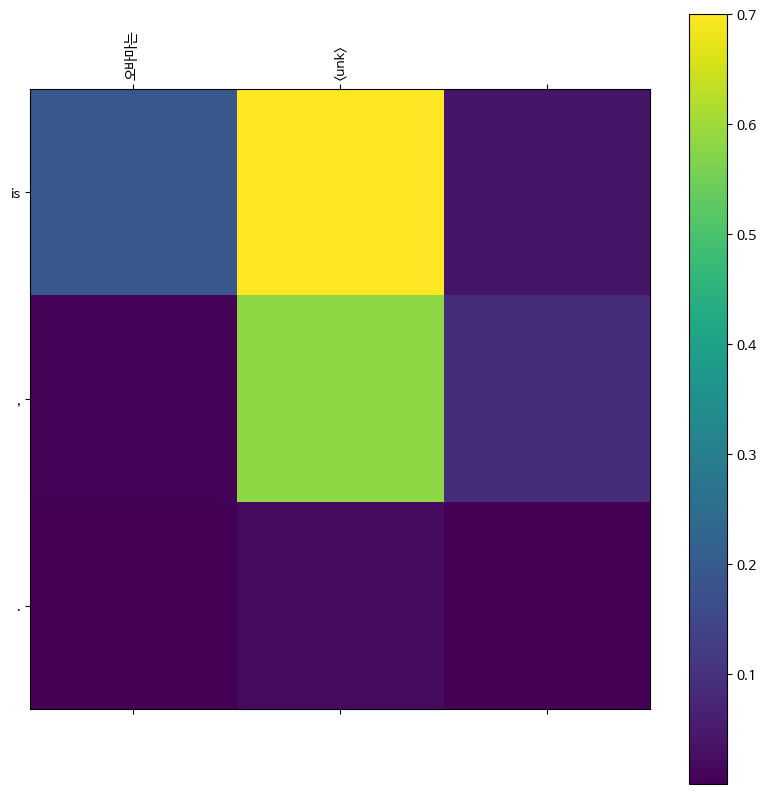

--------------------------------------------------
Input: 시민들은 도시 속에 산다 .
Predicted translation: s in city city of . .
Visualizing Attention for: 시민들은 도시 속에 산다.


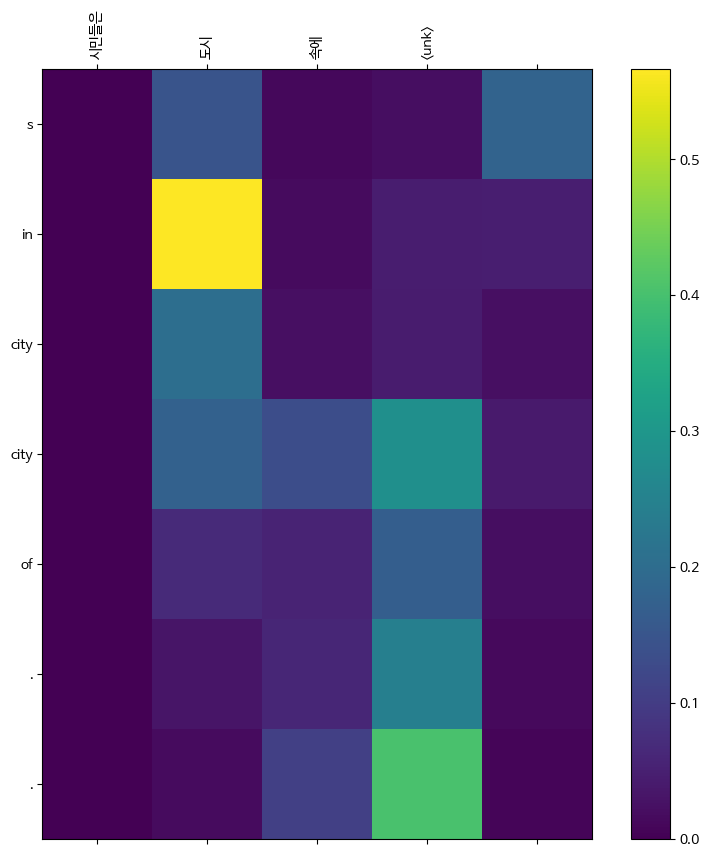

--------------------------------------------------
Input: 커피는 필요 없다 .
Predicted translation: can you do you knives <unk> knives <unk> .
Visualizing Attention for: 커피는 필요 없다.


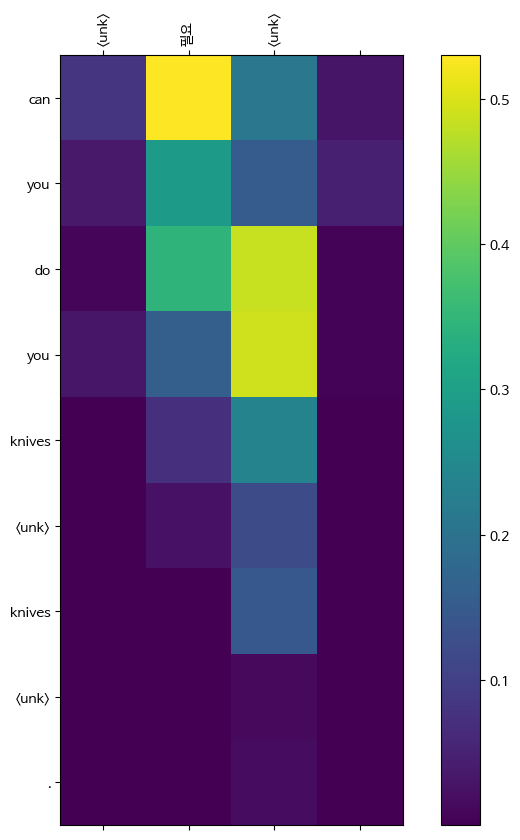

--------------------------------------------------
Input: 일곱 명의 사망자가 발생했다 .
Predicted translation: were were in in in in in blast
Visualizing Attention for: 일곱 명의 사망자가 발생했다.


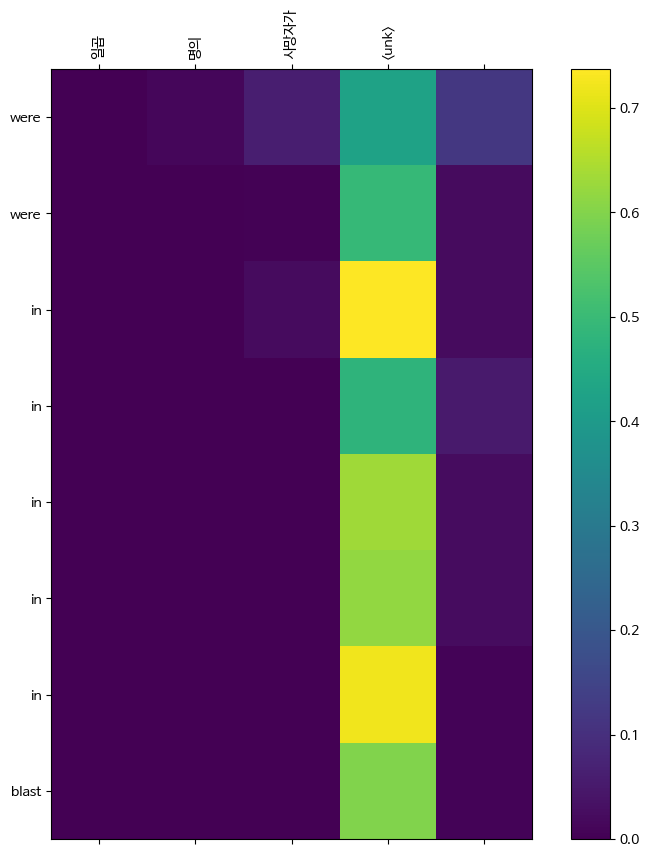

--------------------------------------------------


In [93]:
for sent in test_sentences:
    res_words, attn = translate(sent, model, kor_tokenizer, eng_tokenizer)
    s_ids = kor_tokenizer.texts_to_sequences([sent])[0]
    s_words = [kor_tokenizer.index_word.get(i, "") for i in s_ids if i != 0]
    
    print(f"Visualizing Attention for: {sent}")
    plot_attention(attn, s_words, res_words)
    print("-" * 50)